In [1]:
import matplotlib.pyplot as plt
import torch
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "exclude": "images",
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config["shifter"] = False
model_config["perspective"] = True

In [4]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [5]:
validation_score, trainer_output, state_dict = standard_trainer(
    model, 
    dataloaders, 
    random_seed, 
    max_iter=2, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective'
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 2: 100%|██████████| 35/35 [00:03<00:00,  9.77it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁█
val/poisson_loss,█▁
final/validation_corr_all,0.10599
final/validation_corr_mean,0.10599
val/correlation,0.08972
val/poisson_loss,2591976.75


In [6]:
validation_score

np.float32(0.10599478)

In [7]:
list(model.perspective.parameters())

[Parameter containing:
 tensor([-0.0177, -0.0315, -0.0554,  0.0058, -0.0185, -0.0253, -0.0237,  0.0273,
         -0.0238,  0.0317, -0.0341, -0.0384, -0.1224,  0.0036, -0.0541, -0.0286],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[0.7052],
         [0.6974],
         [0.8869],
         [0.7792],
         [0.1190],
         [0.5207],
         [0.3065],
         [0.5135],
         [0.7859],
         [0.5536],
         [0.5420],
         [0.2341],
         [0.6214],
         [0.5082],
         [0.3833],
         [0.7973]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[ 0.5724, -0.4181],
         [ 0.2286,  0.6613],
         [ 0.6599,  0.6746],
         [ 0.4560, -0.6782],
         [-0.3448,  0.0143],
         [ 0.0911, -0.5847],
         [-0.2359,  0.2507],
         [ 0.4045,  0.3195],
         [ 0.6265, -0.5251],
         [-0.0713, -0.6370],
         [-0.6208, -0.0403],
         [-0.2857, -0.0641],
         [-0.2192,  0.6993],
  

img shape: torch.Size([128, 36, 64])
perspective output shape: torch.Size([128, 36, 54])


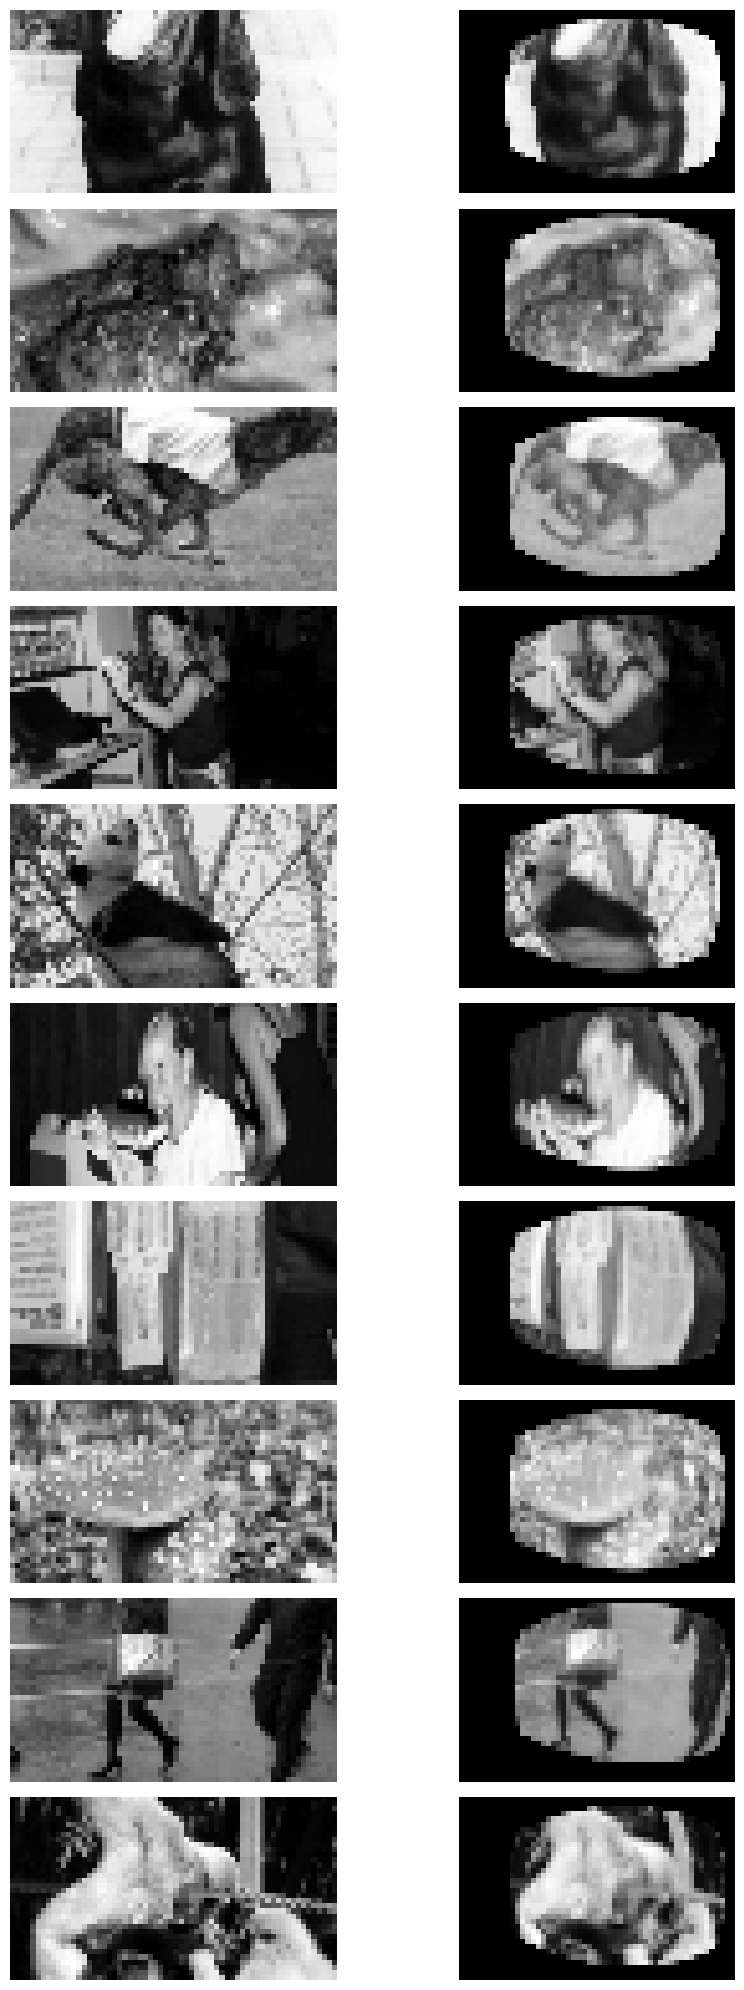

In [8]:
model.to(device)
data_key = "23343-5-17"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

imgs = batch.images[:, 0].detach().cpu()
out = model.perspective[data_key](batch.images, batch.pupil_center)[:, 0].detach().cpu()
print("img shape:", imgs.shape)
print("perspective output shape:", out.shape)

for i in range(10):
    ax[i, 0].imshow(imgs[i], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
img = batch.images
pupil_center = batch.pupil_center
out = model(img, data_key=data_key, pupil_center=batch.pupil_center)
out.backward()
grads = img.grad.squeeze()

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


RuntimeError: grad can be implicitly created only for scalar outputs

In [20]:
img.grad

In [ ]:
batch.behavior

In [ ]:
batch.images.shape

In [ ]:
model.perspective[data_key].retina.mlp

In [ ]:
angles = model.perspective[data_key].retina.mlp(batch.pupil_center).detach().cpu().numpy()

In [ ]:
plt.scatter(angles[:, 0], angles[:, 1])